#TELECOMMUNICATION CUSTOMER CHURN PREDICTION

In [ ]:
# Data Manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (LabelEncoder,OneHotEncoder,StandardScaler,MinMaxScaler)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
from google.colab import files
files = files.upload()

Saving customer_churn.csv to customer_churn.csv


In [ ]:
df = pd.read_csv("customer_churn.csv")
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [ ]:
print("Dataset shape",df.shape)

Dataset shape (100000, 9)


In [ ]:
df.info() # Dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  object 
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  object 
 6   PaymentMethod   100000 non-null  object 
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 6.9+ MB


In [ ]:
df.isnull().sum() # check of missing values

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
MonthlyCharges,0
Contract,0
PaymentMethod,0
TotalCharges,0
Churn,0


In [ ]:
df.duplicated().sum() # check of duplicated rows

np.int64(0)

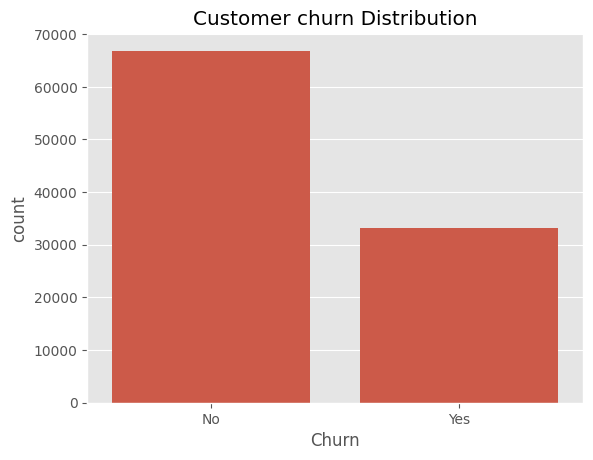

In [ ]:
sns.countplot(data=df,x="Churn")
plt.title("Customer churn Distribution")
plt.show()

In [ ]:
# creating a copy of the dataset
df_model = df.copy()

In [ ]:
# Removing CustomerID
df_model.drop("CustomerID",axis=1,inplace=True)

In [ ]:
# Separating numerical and categorical features
numerical_columns = df_model.select_dtypes(include=["int64","float64"]).columns.tolist()

categorical_columns = df_model.select_dtypes(include=["object"]).columns.tolist()
#print(numerical_columns)

In [ ]:
# Encoding the target variable
target_encoder = LabelEncoder()
df_model["Churn"] = target_encoder.fit_transform(df_model["Churn"])

print(df_model["Churn"].value_counts())

Churn
0    66856
1    33144
Name: count, dtype: int64


In [ ]:
categorical_features = ["Gender","Contract","PaymentMethod"]

df_model = pd.get_dummies(df_model,columns=categorical_features,drop_first=True)
# Convert boolean columns created by get_dummies to integers (0 or 1)
df_model = df_model.astype(int, errors='ignore')
df_model.head()

,Age,Tenure,MonthlyCharges,TotalCharges,Churn,Gender_Male,Gender_Other,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,56,68,147,10052,0,0,0,0,1,0,0,0
1,69,32,22,686,0,1,0,0,0,0,0,1
2,46,10,52,537,0,0,0,1,0,0,1,0
3,32,22,109,2390,1,1,0,0,0,0,0,1
4,60,54,130,7081,0,0,0,0,0,1,0,0


In [ ]:
# splitting features and target
X = df_model.drop("Churn",axis=1)
y = df_model["Churn"]

# Ensure all boolean columns in X are converted to int
for col in X.select_dtypes(include='bool').columns:
    X[col] = X[col].astype(int)

In [ ]:
# Standardizing  numerical features
scaler = StandardScaler()
numerical_features = ["Age","Tenure","MonthlyCharges","TotalCharges"]
X[numerical_features] = scaler.fit_transform(X[numerical_features])

In [ ]:
# Train-Test-Split
from sklearn.model_selection import train_test_split

# Splitting  data into training (80%) and testing (20%) first
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Splitting  training data into actual training (70%) and validation (10%)
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=(0.1/0.8), random_state=42, stratify=y_temp)

print("Training set:",X_train.shape)
print("Validation set:",X_valid.shape)
print("Testing set:",X_test.shape)

Training set: (70000, 11)
Validation set: (10000, 11)
Testing set: (20000, 11)


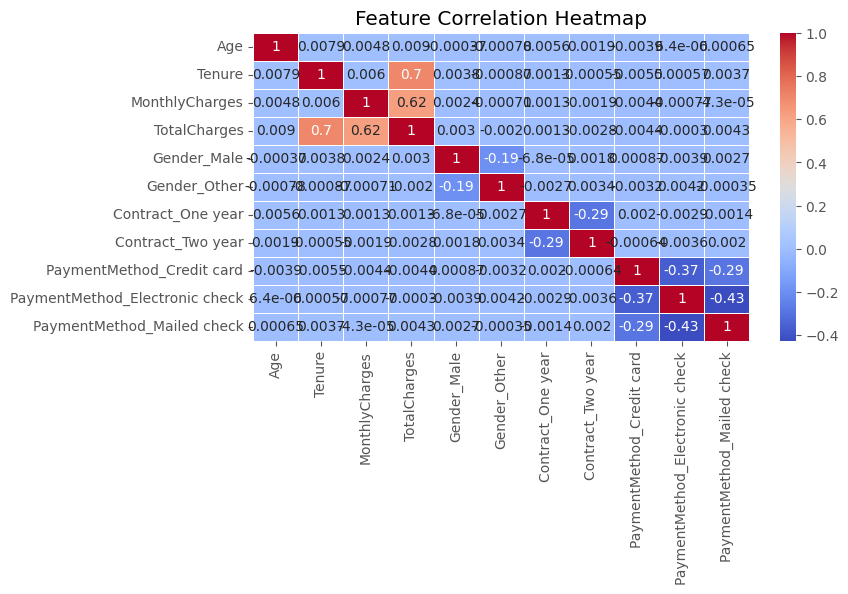

In [ ]:
plt.figure(figsize=(8,4))
sns.heatmap(X.corr(),annot=True,cmap="coolwarm",linewidths=0.5)

plt.title("Feature Correlation Heatmap")
plt.show()

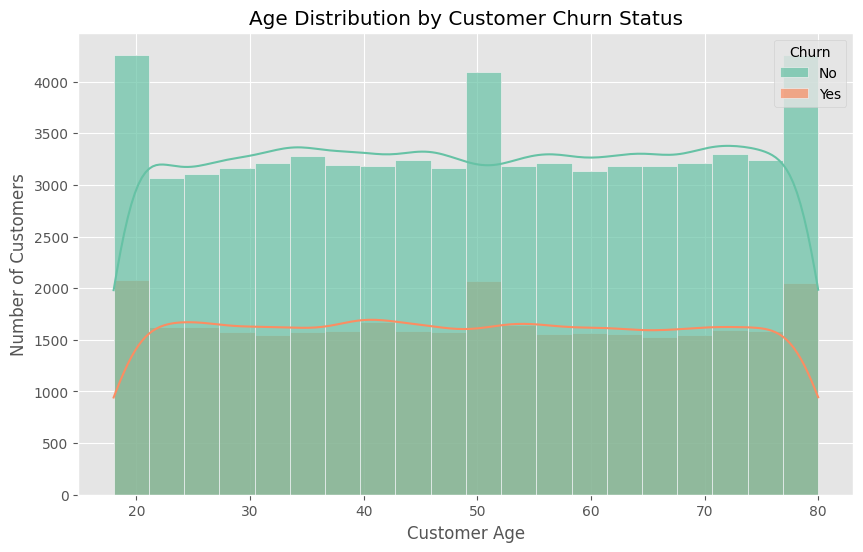

In [ ]:
# Age distribution by churn status
plt.figure(figsize=(10,6))
sns.histplot(data=df,x="Age",hue="Churn",bins=20,kde=True,alpha=0.7,palette="Set2")
plt.title("Age Distribution by Customer Churn Status")
plt.xlabel("Customer Age")
plt.ylabel("Number of Customers")
plt.show()

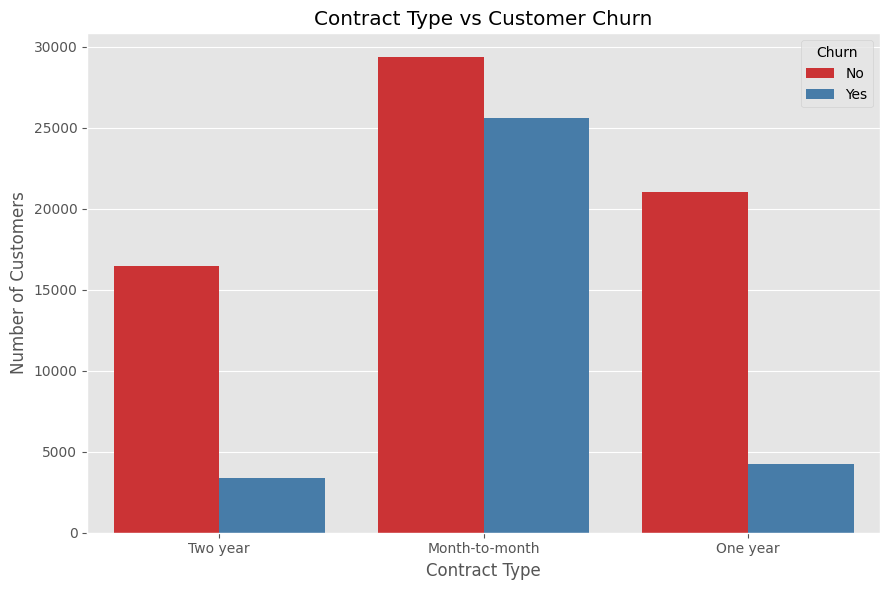

In [ ]:
# Contract type vs churn
plt.figure(figsize=(9,6))
sns.countplot(data=df,x="Contract",hue="Churn",palette="Set1")
plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


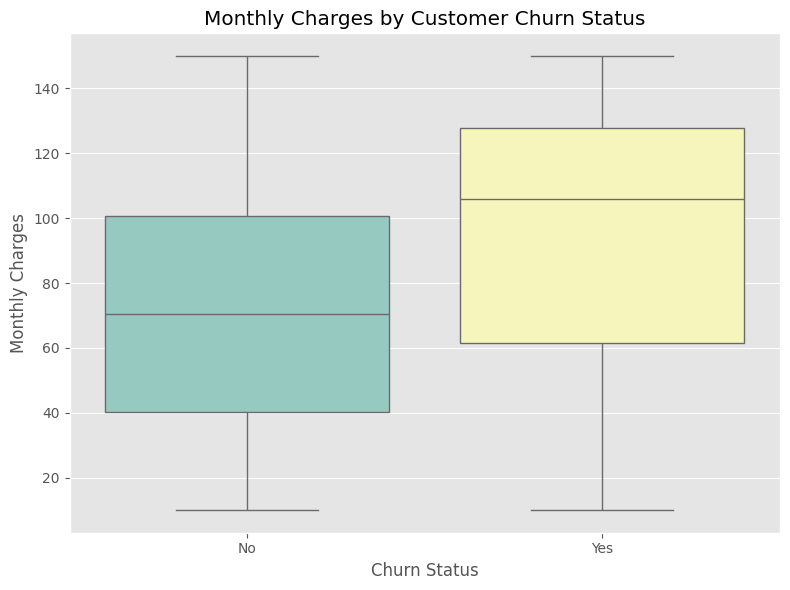

In [ ]:
# Monthly charges by churn status
plt.figure(figsize=(8,6))
sns.boxplot(data=df,x="Churn",y="MonthlyCharges",hue="Churn",palette="Set3",legend=False)
plt.title("Monthly Charges by Customer Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

# Building the Recurrent Neural Network (RNN)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (SimpleRNN,Dense,Dropout)
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint

from sklearn.metrics import (accuracy_score,precision_score,recall_score,roc_auc_score,
                        f1_score,confusion_matrix,classification_report,roc_curve)

###An RNN expects a 3D input i.e (Number of samples,Time Steps,Number of Features).
###Since each customer has one observation,so each feature would be treat as one time step.

In [ ]:
# Converting DataFrame to Numpy arrays
X_train_array = X_train.values
X_valid_array = X_valid.values
X_test_array = X_test.values

# Reshaping into 3D tensors
X_train_rnn = X_train_array.reshape(X_train_array.shape[0],X_train_array.shape[1],1)
X_valid_rnn = X_valid_array.reshape(X_valid_array.shape[0],X_valid_array.shape[1],1)
X_test_rnn = X_test_array.reshape(X_test_array.shape[0],X_test_array.shape[1],1)

print("Training set:",X_train_rnn.shape)
print("Validation set:",X_valid_rnn.shape)
print("Testing set:",X_test_rnn.shape)

Training set: (70000, 11, 1)
Validation set: (10000, 11, 1)
Testing set: (20000, 11, 1)


In [ ]:
# Building the RNN model
rnn_model = Sequential()

# Input Layer
rnn_model.add(tf.keras.Input(shape=(X_train_rnn.shape[1], X_train_rnn.shape[2])))

# First RNN Layer
rnn_model.add(SimpleRNN(units=64,activation="tanh"))

# Dropout layer
rnn_model.add(Dropout(0.30))

# Hidden Dense Layer
rnn_model.add(Dense(units=32,activation="relu"))

# Output Layer
rnn_model.add(Dense(units=1,activation="sigmoid"))

# Model architecture
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compiling the model
rnn_model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy",tf.keras.metrics.AUC(name="auc")])



In [ ]:
# Configuring callbacks to prevent overfitting and save the best model
early_stop = EarlyStopping(monitor="val_loss",patience=10,restore_best_weights=True)

checkpoint = ModelCheckpoint("best_rnn_model.keras",monitor="val_loss",save_best_only=True)

In [ ]:
# Training the RNN
history = rnn_model.fit(X_train_rnn,y_train,epochs=50,batch_size=32,
                        validation_split=0.2,callbacks=[early_stop,checkpoint],verbose=1)

Epoch 1/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.7283 - auc: 0.7709 - loss: 0.5192 - val_accuracy: 0.7476 - val_auc: 0.7921 - val_loss: 0.4897
Epoch 2/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7403 - auc: 0.7888 - loss: 0.4928 - val_accuracy: 0.7513 - val_auc: 0.7996 - val_loss: 0.4743
Epoch 3/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7438 - auc: 0.7930 - loss: 0.4831 - val_accuracy: 0.7523 - val_auc: 0.8023 - val_loss: 0.4715
Epoch 4/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7461 - auc: 0.7935 - loss: 0.4806 - val_accuracy: 0.7491 - val_auc: 0.7909 - val_loss: 0.4870
Epoch 5/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7484 - auc: 0.7941 - loss: 0.4780 - val_accuracy: 0.7506 - val_auc: 0.7984 - val_loss: 0.4768
Epoch 6/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7496 - auc: 0.7956 - loss: 0.4767 - val_accuracy: 0.7563 - val_auc: 0.8023 - val_loss: 0.4678
Epoch 7/50
2000/2000 ━━

In [ ]:
# Evaluate the model on the test set
loss, accuracy, auc = rnn_model.evaluate(X_test_rnn, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test AUC: {auc:.4f}")

Test Loss: 0.4610
Test Accuracy: 0.7603
Test AUC: 0.8034


In [ ]:
# Generating predictions
y_prob = rnn_model.predict(X_test_rnn)
y_pred = (y_prob >= 0.5).astype(int)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:

# Classification report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.86      0.83     13371
           1       0.67      0.55      0.60      6629

    accuracy                           0.76     20000
   macro avg       0.73      0.71      0.72     20000
weighted avg       0.75      0.76      0.75     20000



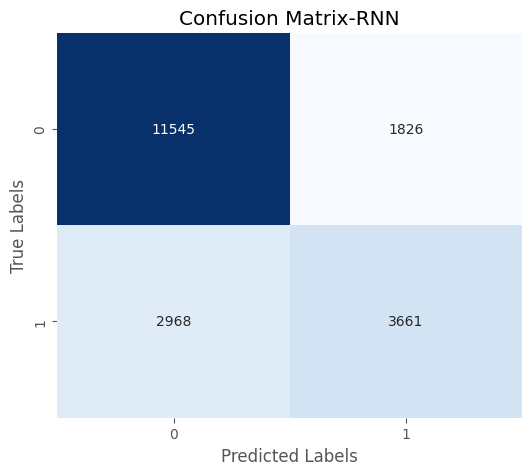

In [ ]:
# Confusion matrix
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",cbar=False)
plt.title("Confusion Matrix-RNN")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


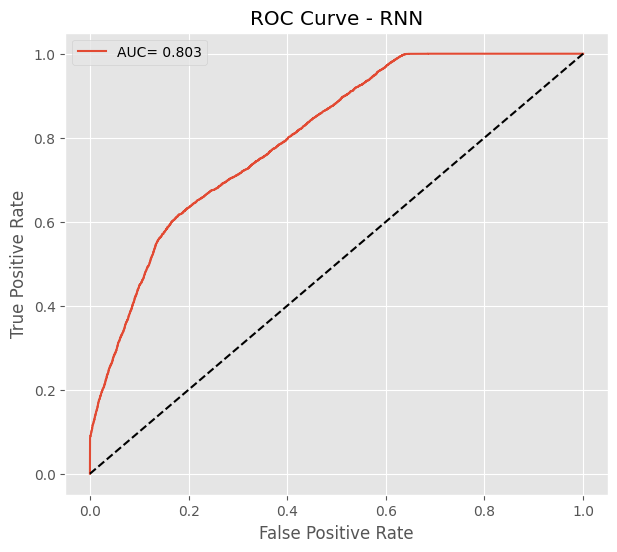

In [ ]:
# ROC CURVE
fpr,tpr,_ = roc_curve(y_test,y_prob)
plt.figure(figsize=(7,6))

plt.plot(fpr,tpr,label=f"AUC= {roc_auc_score(y_test,y_prob):.3f}")

plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - RNN")
plt.legend()
plt.show()

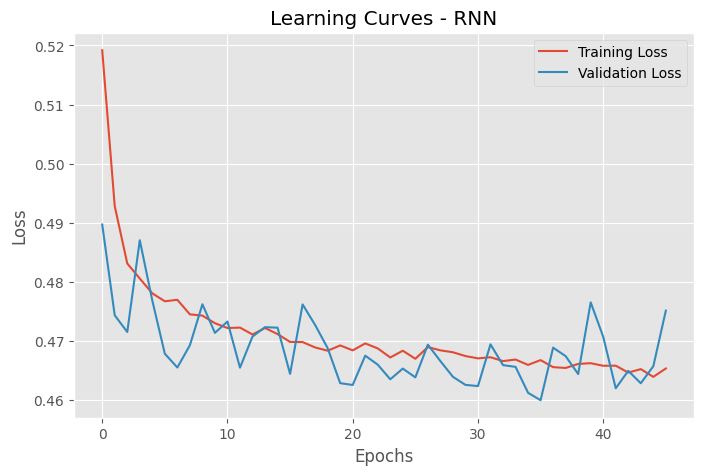

In [ ]:
# Learning Curves
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"],label="Training Loss")

plt.plot(history.history["val_loss"],label="Validation Loss")
plt.title("Learning Curves - RNN")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
#Saving predictions for the stacking model
rnn_train_predictions = rnn_model.predict(X_train_rnn)
rnn_valid_predictions = rnn_model.predict(X_valid_rnn)
rnn_test_predictions = rnn_model.predict(X_test_rnn)

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


# Simplified Discrete-Time Hazard Model

In [ ]:

# Creating hazard dataset

hazard_df = df_model.copy()

hazard_df.head()

,Age,Tenure,MonthlyCharges,TotalCharges,Churn,Gender_Male,Gender_Other,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,56,68,147,10052,0,0,0,0,1,0,0,0
1,69,32,22,686,0,1,0,0,0,0,0,1
2,46,10,52,537,0,0,0,1,0,0,1,0
3,32,22,109,2390,1,1,0,0,0,0,0,1
4,60,54,130,7081,0,0,0,0,0,1,0,0


In [ ]:
# Creating Tenure Intervals


hazard_df["Tenure_Group"] = pd.cut(

    hazard_df["Tenure"],

    bins=[0, 12, 24, 48, 72],

    labels=[
        "Year_1",
        "Year_2",
        "Year_3",
        "Year_4"
    ],

    include_lowest=True
)

hazard_df[
    ["Tenure", "Tenure_Group"]
].head(15)

,Tenure,Tenure_Group
0,68,Year_4
1,32,Year_3
2,10,Year_1
3,22,Year_2
4,54,Year_4
5,29,Year_3
6,20,Year_2
7,11,Year_1
8,43,Year_3
9,62,Year_4


In [ ]:
# Distribution of time interval

print(
    hazard_df["Tenure_Group"]
    .value_counts()
    .sort_index()
)

Tenure_Group
Year_1    16647
Year_2    16637
Year_3    33332
Year_4    33384
Name: count, dtype: int64


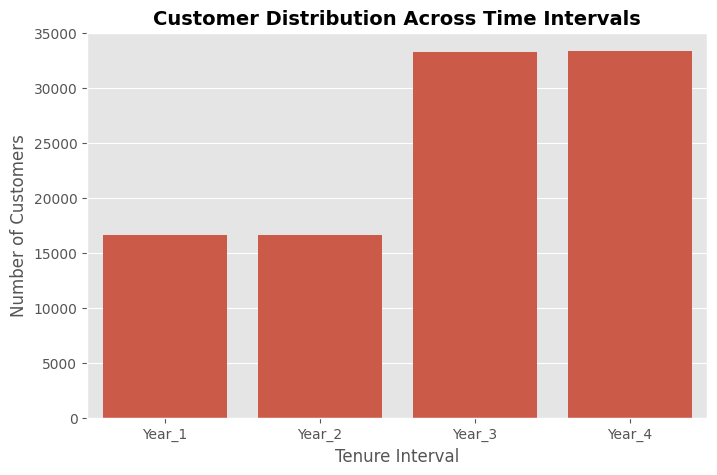

In [ ]:
# Tenure Group Distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=hazard_df,
    x="Tenure_Group",
    order=[
        "Year_1",
        "Year_2",
        "Year_3",
        "Year_4"
    ]
)

plt.title(
    "Customer Distribution Across Time Intervals",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Tenure Interval")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
# Computing Hazard Probabilities

hazard_table = (

    hazard_df
    .groupby("Tenure_Group", observed=False)["Churn"]
    .agg(
        Customers="count",
        Churned="sum"
    )
)

hazard_table["Hazard_Probability"] = (

    hazard_table["Churned"] /
    hazard_table["Customers"]

)

hazard_table

,Customers,Churned,Hazard_Probability
Tenure_Group,,,
Year_1,16647,10655,0.640055
Year_2,16637,4471,0.268738
Year_3,33332,8952,0.268571
Year_4,33384,9066,0.271567


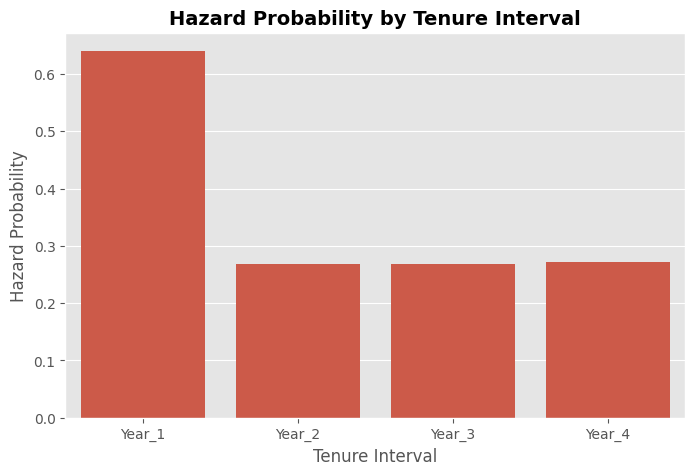

In [ ]:
# Hazard Probability plot
plt.figure(figsize=(8, 5))

sns.barplot(x=hazard_table.index, y=hazard_table["Hazard_Probability"])

plt.title(
    "Hazard Probability by Tenure Interval",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Tenure Interval")
plt.ylabel("Hazard Probability")

plt.show()

In [ ]:
# Creating Customer Hazard Feature

hazard_mapping = ( hazard_table["Hazard_Probability"].to_dict())

hazard_df["Hazard_Probability"] = (hazard_df["Tenure_Group"].map(hazard_mapping))

hazard_df[
    [
        "Tenure",
        "Tenure_Group",
        "Hazard_Probability"
    ]
].head(10)

,Tenure,Tenure_Group,Hazard_Probability
0,68,Year_4,0.271567
1,32,Year_3,0.268571
2,10,Year_1,0.640055
3,22,Year_2,0.268738
4,54,Year_4,0.271567
5,29,Year_3,0.268571
6,20,Year_2,0.268738
7,11,Year_1,0.640055
8,43,Year_3,0.268571
9,62,Year_4,0.271567


# Survival Analysis

In [ ]:
# Computing interval survival probabilities

survival_table = hazard_table.copy()

survival_table["Interval_Survival"] = ( 1 - survival_table["Hazard_Probability"])

survival_table

,Customers,Churned,Hazard_Probability,Interval_Survival
Tenure_Group,,,,
Year_1,16647,10655,0.640055,0.359945
Year_2,16637,4471,0.268738,0.731262
Year_3,33332,8952,0.268571,0.731429
Year_4,33384,9066,0.271567,0.728433


In [ ]:
# Computing cummulative Survival Probability

survival_table["Survival_Probability"] = ( survival_table["Interval_Survival"].cumprod())

survival_table

,Customers,Churned,Hazard_Probability,Interval_Survival,Survival_Probability
Tenure_Group,,,,,
Year_1,16647,10655,0.640055,0.359945,0.359945
Year_2,16637,4471,0.268738,0.731262,0.263214
Year_3,33332,8952,0.268571,0.731429,0.192522
Year_4,33384,9066,0.271567,0.728433,0.140240


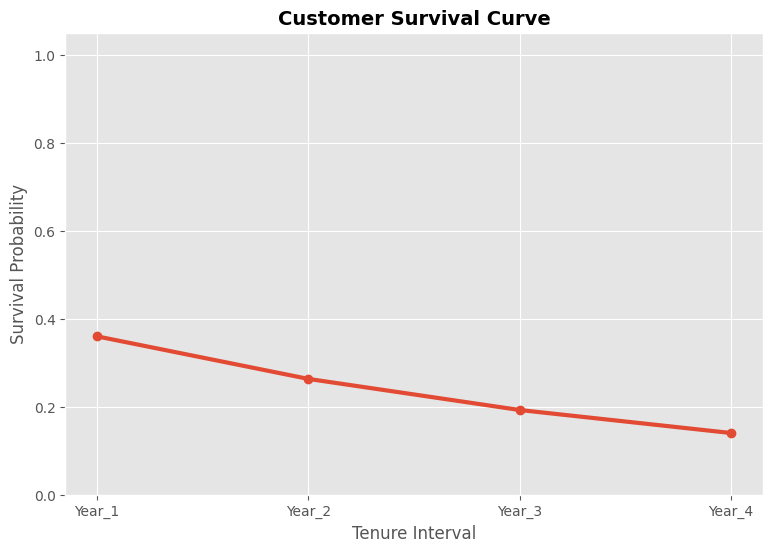

In [ ]:
# Survival Curve
plt.figure(figsize=(9, 6))

plt.plot(survival_table.index,survival_table["Survival_Probability"],marker="o",linewidth=3)

plt.title(
    "Customer Survival Curve",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Tenure Interval")
plt.ylabel("Survival Probability")

plt.ylim(0, 1.05)
plt.grid(True)

plt.show()

In [ ]:
# Estimating Time-To-Churn

below_half = survival_table[survival_table["Survival_Probability"] < 0.50]

if len(below_half) > 0:

    median_survival = below_half.index[0]

    print(f"Estimated Median Time-to-Churn: {median_survival}")

else:

    print("More than 50% of customers survive through all intervals.")

Estimated Median Time-to-Churn: Year_1


In [ ]:
# Mapping Survival Probability to Customers

survival_mapping = (survival_table["Survival_Probability"].to_dict())

hazard_df["Survival_Probability"] = (hazard_df["Tenure_Group"].map(survival_mapping))

hazard_df[
    [
        "Tenure",
        "Tenure_Group",
        "Hazard_Probability",
        "Survival_Probability"
    ]
].head()

,Tenure,Tenure_Group,Hazard_Probability,Survival_Probability
0,68,Year_4,0.271567,0.140240
1,32,Year_3,0.268571,0.192522
2,10,Year_1,0.640055,0.359945
3,22,Year_2,0.268738,0.263214
4,54,Year_4,0.271567,0.140240


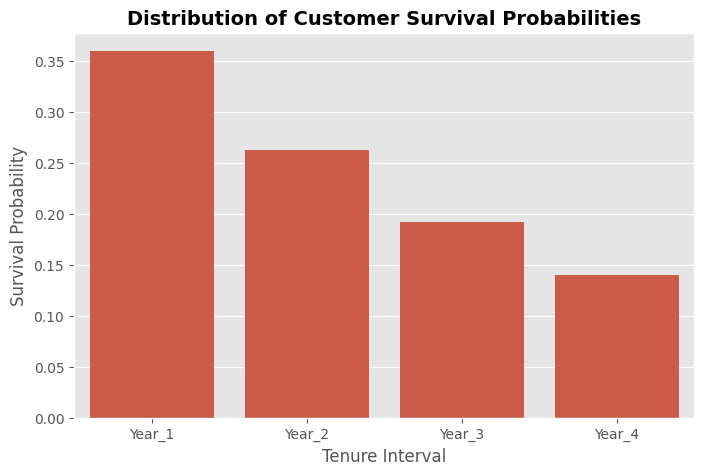

In [ ]:
# Distribution of Survival Probabilities

plt.figure(figsize=(8, 5))

sns.barplot(x=survival_table.index, y=survival_table["Survival_Probability"])

plt.title(
    "Distribution of Customer Survival Probabilities",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Tenure Interval")
plt.ylabel("Survival Probability")

plt.show()

## Verifying The Three Meta Features

In [ ]:
# RNN PREDICTIONS
rnn_test_predictions

array([[1.4060625e-04],
       [9.6811767e-05],
       [4.0687162e-05],
       ...,
       [3.0576307e-01],
       [5.7627261e-01],
       [6.2119097e-01]], dtype=float32)

In [ ]:
# HAZARD MODEL
hazard_df["Hazard_Probability"]

,Hazard_Probability
0,0.271567
1,0.268571
2,0.640055
3,0.268738
4,0.271567
...,...
99995,0.271567
99996,0.268571
99997,0.268571
99998,0.271567


In [ ]:
# SURVIVAL MODEL
hazard_df["Survival_Probability"]

,Survival_Probability
0,0.140240
1,0.192522
2,0.359945
3,0.263214
4,0.140240
...,...
99995,0.140240
99996,0.192522
99997,0.192522
99998,0.140240


## Creating the Meta Dataset

In [ ]:
# Creating a custom level test DataFrame first since the RNN predictions were generated on x_test

# Recreating  the processed test dataset
meta_test_df = X_test.copy()

# Adding  the true target
meta_test_df["Churn"] = y_test.values

print(meta_test_df.shape)

meta_test_df.head()

(20000, 12)


,Age,Tenure,MonthlyCharges,TotalCharges,Gender_Male,Gender_Other,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
82165,1.153759,0.263254,-1.641837,-0.984717,0,1,1,0,0,1,0,0
87164,-0.771670,1.610091,-0.110638,0.970354,0,0,1,0,1,0,0,0
17248,0.383587,0.599963,-0.752754,-0.192890,1,0,1,0,0,0,1,0
92852,-1.211768,0.215153,-0.209425,-0.001109,1,0,0,0,0,0,0,0
22025,-1.321792,-1.708900,1.247683,-1.194921,0,1,1,0,1,0,0,0


In [ ]:
# Assigning  Hazard and Survival Features

meta_test_df["Hazard_Probability"] = (
    hazard_df.loc[
        meta_test_df.index,
        "Hazard_Probability"
    ].values
)

meta_test_df["Survival_Probability"] = (
    hazard_df.loc[
        meta_test_df.index,
        "Survival_Probability"
    ].values
)

meta_test_df.head()

,Age,Tenure,MonthlyCharges,TotalCharges,Gender_Male,Gender_Other,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn,Hazard_Probability,Survival_Probability
82165,1.153759,0.263254,-1.641837,-0.984717,0,1,1,0,0,1,0,0,0.268571,0.192522
87164,-0.771670,1.610091,-0.110638,0.970354,0,0,1,0,1,0,0,0,0.271567,0.140240
17248,0.383587,0.599963,-0.752754,-0.192890,1,0,1,0,0,0,1,0,0.271567,0.140240
92852,-1.211768,0.215153,-0.209425,-0.001109,1,0,0,0,0,0,0,0,0.268571,0.192522
22025,-1.321792,-1.708900,1.247683,-1.194921,0,1,1,0,1,0,0,0,0.640055,0.359945


In [ ]:
# Adding RNN predictions

meta_test_df["RNN_Probability"] = (
    rnn_test_predictions.flatten()
)

meta_test_df.head()

,Age,Tenure,MonthlyCharges,TotalCharges,Gender_Male,Gender_Other,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn,Hazard_Probability,Survival_Probability,RNN_Probability
82165,1.153759,0.263254,-1.641837,-0.984717,0,1,1,0,0,1,0,0,0.268571,0.192522,0.000141
87164,-0.771670,1.610091,-0.110638,0.970354,0,0,1,0,1,0,0,0,0.271567,0.140240,0.000097
17248,0.383587,0.599963,-0.752754,-0.192890,1,0,1,0,0,0,1,0,0.271567,0.140240,0.000041
92852,-1.211768,0.215153,-0.209425,-0.001109,1,0,0,0,0,0,0,0,0.268571,0.192522,0.306281
22025,-1.321792,-1.708900,1.247683,-1.194921,0,1,1,0,1,0,0,0,0.640055,0.359945,0.568707


## Creating the Meta Feature Matrix

In [ ]:
X_meta = meta_test_df[
    [
        "RNN_Probability",
        "Hazard_Probability",
        "Survival_Probability"
    ]
]

y_meta = meta_test_df["Churn"]

print("Meta Feature Shape :", X_meta.shape)
print("Target Shape       :", y_meta.shape)

X_meta.head()

Meta Feature Shape : (20000, 3)
Target Shape       : (20000,)


,RNN_Probability,Hazard_Probability,Survival_Probability
82165,0.000141,0.268571,0.192522
87164,0.000097,0.271567,0.140240
17248,0.000041,0.271567,0.140240
92852,0.306281,0.268571,0.192522
22025,0.568707,0.640055,0.359945


In [ ]:
# Preparing the Meta-Learner Training Data
# Creating  validation meta dataset
meta_valid_df = pd.DataFrame({

    "RNN_Probability": rnn_valid_predictions.flatten(),

    "Hazard_Probability": hazard_df.loc[
        X_valid.index,
        "Hazard_Probability"
    ].values,

    "Survival_Probability": hazard_df.loc[
        X_valid.index,
        "Survival_Probability"
    ].values,

    "Churn": y_valid.values

})

meta_valid_df.head()

,RNN_Probability,Hazard_Probability,Survival_Probability,Churn
0,0.409365,0.640055,0.359945,0
1,0.348493,0.271567,0.140240,1
2,0.677323,0.271567,0.140240,0
3,0.000032,0.268571,0.192522,0
4,0.716783,0.640055,0.359945,1


In [ ]:
# Preparing the meta learner test data

meta_test_df = pd.DataFrame({

    "RNN_Probability": rnn_test_predictions.flatten(),

    "Hazard_Probability": hazard_df.loc[
        X_test.index,
        "Hazard_Probability"
    ].values,

    "Survival_Probability": hazard_df.loc[
        X_test.index,
        "Survival_Probability"
    ].values,

    "Churn": y_test.values

})

meta_test_df.head()

,RNN_Probability,Hazard_Probability,Survival_Probability,Churn
0,0.000141,0.268571,0.192522,0
1,0.000097,0.271567,0.140240,0
2,0.000041,0.271567,0.140240,0
3,0.306281,0.268571,0.192522,0
4,0.568707,0.640055,0.359945,0


In [ ]:
# Creating matrix feature

X_meta_train = meta_valid_df.drop(
    columns="Churn"
)

y_meta_train = meta_valid_df["Churn"]

X_meta_test = meta_test_df.drop(
    columns="Churn"
)

y_meta_test = meta_test_df["Churn"]

print("Training Shape :", X_meta_train.shape)
print("Testing Shape :", X_meta_test.shape)

Training Shape : (10000, 3)
Testing Shape : (20000, 3)


## Standardizing the meta features

In [ ]:
from sklearn.preprocessing import StandardScaler

meta_scaler = StandardScaler()

X_meta_train_scaled = meta_scaler.fit_transform(
    X_meta_train
)

X_meta_test_scaled = meta_scaler.transform(
    X_meta_test
)

## Initializing the Logistics Regression Meta-Learner

In [ ]:

from sklearn.linear_model import LogisticRegression

meta_model = LogisticRegression(

    class_weight="balanced",

    random_state=42,

    max_iter=1000

)

print(meta_model)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)


In [ ]:
# Training the meta-learner model
meta_model.fit(X_meta_train_scaled,y_meta_train)

print("Logistic Regression Meta-Learner trained successfully.")

Logistic Regression Meta-Learner trained successfully.


In [ ]:
# Generating final probabilites
final_probabilities = meta_model.predict_proba(X_meta_test_scaled)[:, 1]

print(final_probabilities[:10])

[0.08812597 0.09048673 0.09045861 0.38396281 0.74993786 0.88285035
 0.0881258  0.09046691 0.38812642 0.39179028]


In [ ]:
# converting probabilities to class labels
final_predictions = (final_probabilities >= 0.50).astype(int)

print(final_predictions[:10])

[0 0 0 0 1 1 0 0 0 0]


# Selecting Threshold Optimization

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import (accuracy_score,precision_score,recall_score,
    f1_score,roc_auc_score,confusion_matrix,classification_report,
    roc_curve,precision_recall_curve)

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Finding the optimal threshold
thresholds = np.arange(0.10, 0.91, 0.01)
results = []

for threshold in thresholds:

    predictions = (
        final_probabilities >= threshold
    ).astype(int)

    results.append({

        "Threshold": threshold,

        "Accuracy": accuracy_score(
            y_meta_test,
            predictions
        ),

        "Precision": precision_score(
            y_meta_test,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_meta_test,
            predictions,
            zero_division=0
        ),

        "F1 Score": f1_score(
            y_meta_test,
            predictions,
            zero_division=0
        )

    })

threshold_results = pd.DataFrame(results)

threshold_results.head()

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.10,0.56730,0.433733,0.999698,0.604984
1,0.11,0.56895,0.434663,0.999547,0.605861
2,0.12,0.57035,0.435454,0.999397,0.606602
3,0.13,0.57140,0.436056,0.999397,0.607185
4,0.14,0.57200,0.436384,0.999095,0.607447


In [ ]:
# Selecting the best threshold
best_row = threshold_results.loc[
    threshold_results["F1 Score"].idxmax()]

best_threshold = best_row["Threshold"]

print(f"Optimal Threshold : {best_threshold:.2f}")

print(best_row)

Optimal Threshold : 0.44
Threshold    0.440000
Accuracy     0.746450
Precision    0.614357
Recall       0.631317
F1 Score     0.622722
Name: 34, dtype: float64


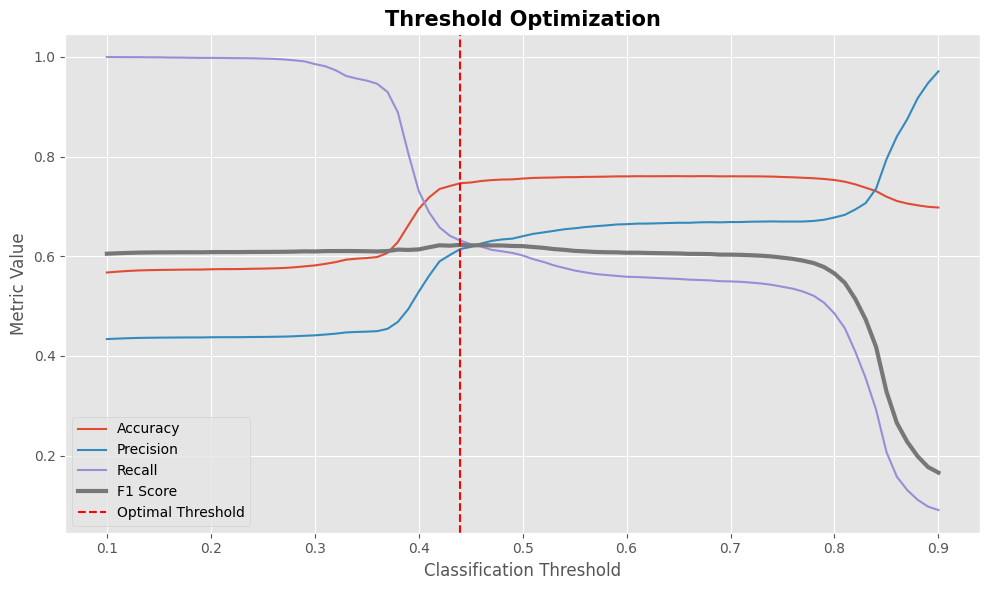

In [ ]:
# Threshold Optimation plot
plt.figure(figsize=(10,6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Accuracy"],
    label="Accuracy"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1 Score"],
    linewidth=3,
    label="F1 Score"
)

plt.axvline(
    best_threshold,
    color="red",
    linestyle="--",
    label="Optimal Threshold"
)

plt.title("Threshold Optimization",fontsize=15,fontweight="bold")

plt.xlabel("Classification Threshold")
plt.ylabel("Metric Value")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Final Predictions
final_predictions = (final_probabilities >= best_threshold).astype(int)

print(final_predictions[:10])

[0 0 0 0 1 1 0 0 0 0]


# Overall Performance metrics

In [ ]:
accuracy = accuracy_score(
    y_meta_test,
    final_predictions)

precision = precision_score(
    y_meta_test,
    final_predictions)

recall = recall_score(
    y_meta_test,
    final_predictions)

f1 = f1_score(
    y_meta_test,
    final_predictions)

roc_auc = roc_auc_score(
    y_meta_test,
    final_probabilities)

print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("=" * 50)

Accuracy : 0.7464
Precision: 0.6144
Recall   : 0.6313
F1 Score : 0.6227
ROC-AUC  : 0.8033


In [ ]:
# classification report
print(classification_report(y_meta_test,final_predictions))

              precision    recall  f1-score   support

           0       0.81      0.80      0.81     13371
           1       0.61      0.63      0.62      6629

    accuracy                           0.75     20000
   macro avg       0.71      0.72      0.72     20000
weighted avg       0.75      0.75      0.75     20000



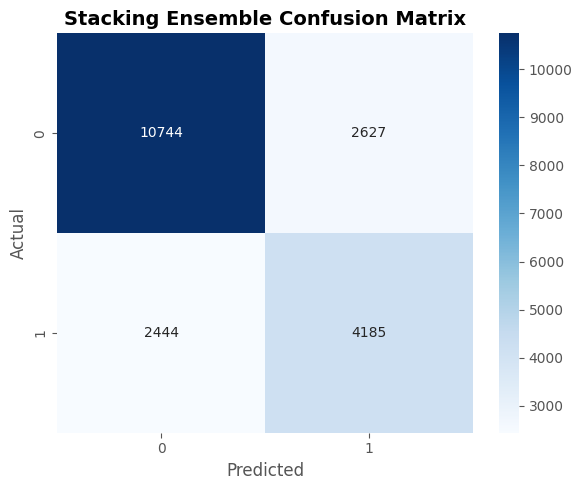

In [ ]:
# confusion matrix
cm = confusion_matrix(y_meta_test,final_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.title("Stacking Ensemble Confusion Matrix",fontsize=14,fontweight="bold")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.show()

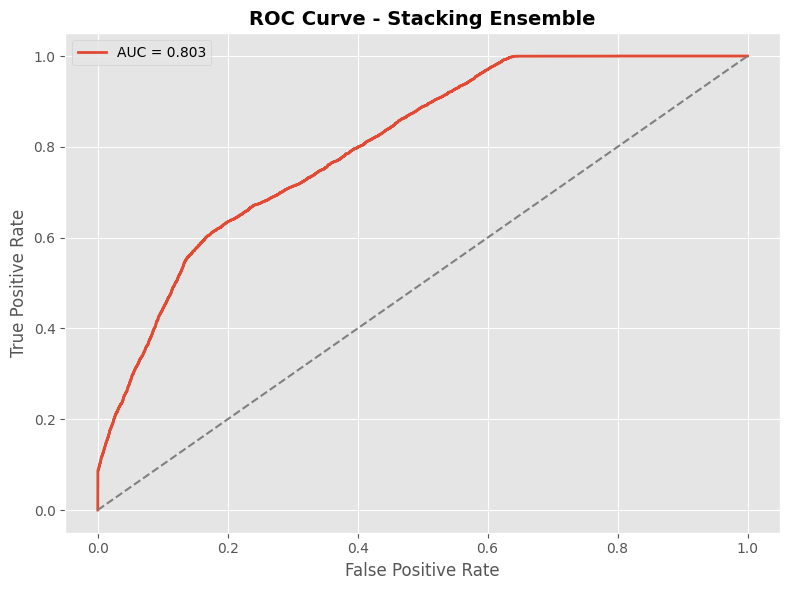

In [ ]:
# ROC-CURVE
fpr, tpr, _ = roc_curve(y_meta_test,final_probabilities)

plt.figure(figsize=(8,6))

plt.plot(fpr,tpr,linewidth=2,label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],linestyle="--",color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Stacking Ensemble",fontsize=14,fontweight="bold")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

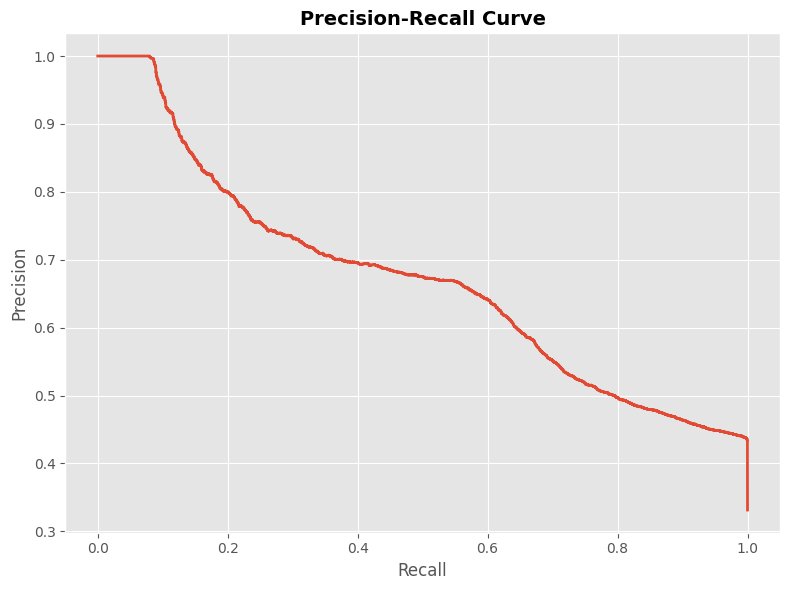

In [ ]:
#Precision recall curve
precision, recall, _ = precision_recall_curve(y_meta_test,final_probabilities)

plt.figure(figsize=(8,6))

plt.plot(recall,precision,linewidth=2)

plt.title("Precision-Recall Curve", fontsize=14,fontweight="bold")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.tight_layout()
plt.show()